![A soccer pitch for an international match.](soccer-pitch.jpg)

You're working as a sports journalist at a major online sports media company, specializing in soccer analysis and reporting. You've been watching both men's and women's international soccer matches for a number of years, and your gut instinct tells you that more goals are scored in women's international football matches than men's. This would make an interesting investigative article that your subscribers are bound to love, but you'll need to perform a valid statistical hypothesis test to be sure!

While scoping this project, you acknowledge that the sport has changed a lot over the years, and performances likely vary a lot depending on the tournament, so you decide to limit the data used in the analysis to only official `FIFA World Cup` matches (not including qualifiers) since `2002-01-01`.

You create two datasets containing the results of every official men's and women's international football match since the 19th century, which you scraped from a reliable online source. This data is stored in two CSV files: `women_results.csv` and `men_results.csv`.

The question you are trying to determine the answer to is:

> Are more goals scored in women's international soccer matches than men's?

You assume a **10% significance level**, and use the following null and alternative hypotheses:

$H_0$ : The mean number of goals scored in women's international soccer matches is the same as men's.

$H_A$ : The mean number of goals scored in women's international soccer matches is greater than men's.

In [155]:
# Start your code here!
import pandas as pd
sig = 0.10 

df_men = pd.read_csv('men_results.csv')
df_women = pd.read_csv('women_results.csv')

In [156]:
# Exploratory Data Analysis
print(df_men.info(), df_women.info()) # We can observe that the date column is an object dtype

# Therefore we convert it to datetime
df_men['date'] = pd.to_datetime(df_men['date'])
df_women['date'] = pd.to_datetime(df_women['date'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44353 entries, 0 to 44352
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  44353 non-null  int64 
 1   date        44353 non-null  object
 2   home_team   44353 non-null  object
 3   away_team   44353 non-null  object
 4   home_score  44353 non-null  int64 
 5   away_score  44353 non-null  int64 
 6   tournament  44353 non-null  object
dtypes: int64(3), object(4)
memory usage: 2.4+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4884 entries, 0 to 4883
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  4884 non-null   int64 
 1   date        4884 non-null   object
 2   home_team   4884 non-null   object
 3   away_team   4884 non-null   object
 4   home_score  4884 non-null   int64 
 5   away_score  4884 non-null   int64 
 6   tournament  4884 non-null   object
dtypes: int64(3)

In [157]:
# Check unique values and how many of those values there are

for column in df_men.columns:
    print(f"Value counts for men {column}:",  df_men[column])

for column in df_women.columns:
    print(f"Value counts for women {column}:", df_women[column])

Value counts for men Unnamed: 0: 0            0
1            1
2            2
3            3
4            4
         ...  
44348    44348
44349    44349
44350    44350
44351    44351
44352    44352
Name: Unnamed: 0, Length: 44353, dtype: int64
Value counts for men date: 0       1872-11-30
1       1873-03-08
2       1874-03-07
3       1875-03-06
4       1876-03-04
           ...    
44348   2022-12-14
44349   2022-12-14
44350   2022-12-17
44351   2022-12-17
44352   2022-12-18
Name: date, Length: 44353, dtype: datetime64[ns]
Value counts for men home_team: 0         Scotland
1          England
2         Scotland
3          England
4         Scotland
           ...    
44348     Thailand
44349      Vietnam
44350      Croatia
44351    Singapore
44352    Argentina
Name: home_team, Length: 44353, dtype: object
Value counts for men away_team: 0            England
1           Scotland
2            England
3           Scotland
4            England
            ...     
44348         Taiwan
44349

In [158]:
# Check for null entries in each column
for column in df_men.columns:
    print(f"Null count in men {column}:", df_men[column].isna().sum())

for column in df_women.columns:
    print(f"Null count in women {column}:", df_women[column].isna().sum())

Null count in men Unnamed: 0: 0
Null count in men date: 0
Null count in men home_team: 0
Null count in men away_team: 0
Null count in men home_score: 0
Null count in men away_score: 0
Null count in men tournament: 0
Null count in women Unnamed: 0: 0
Null count in women date: 0
Null count in women home_team: 0
Null count in women away_team: 0
Null count in women home_score: 0
Null count in women away_score: 0
Null count in women tournament: 0


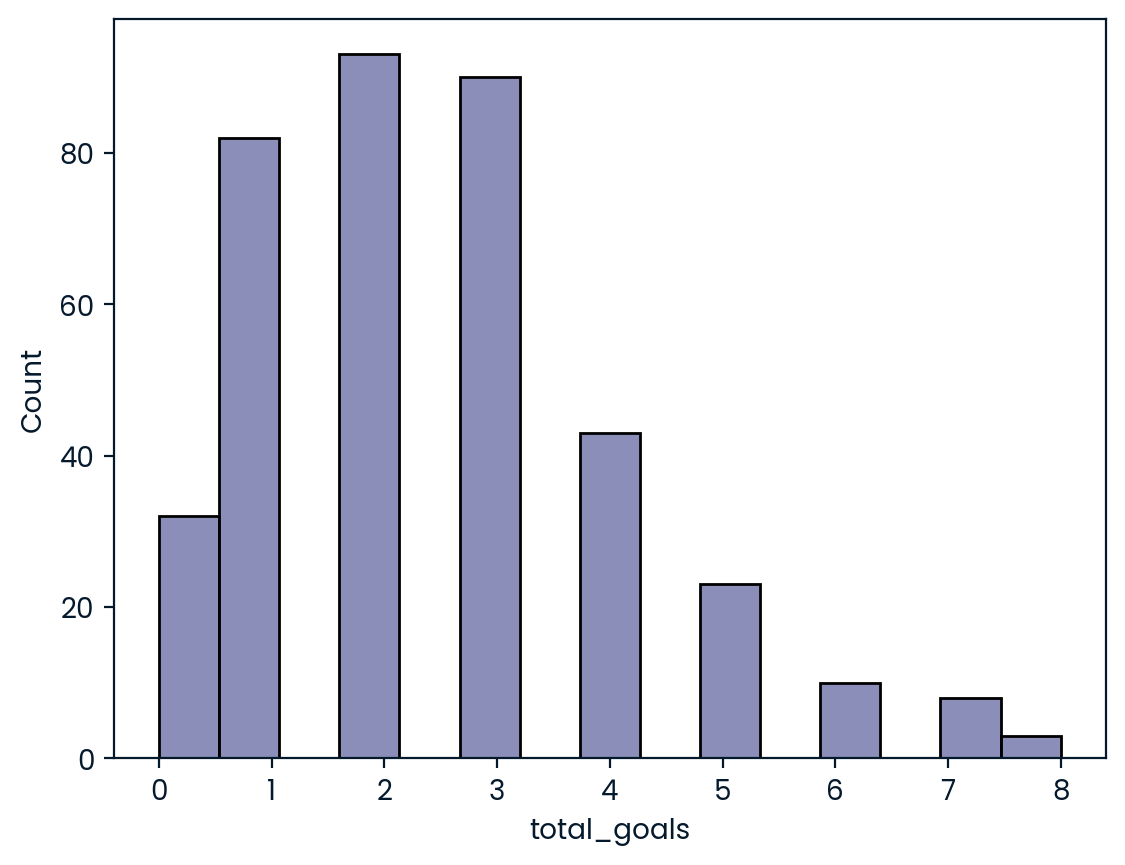

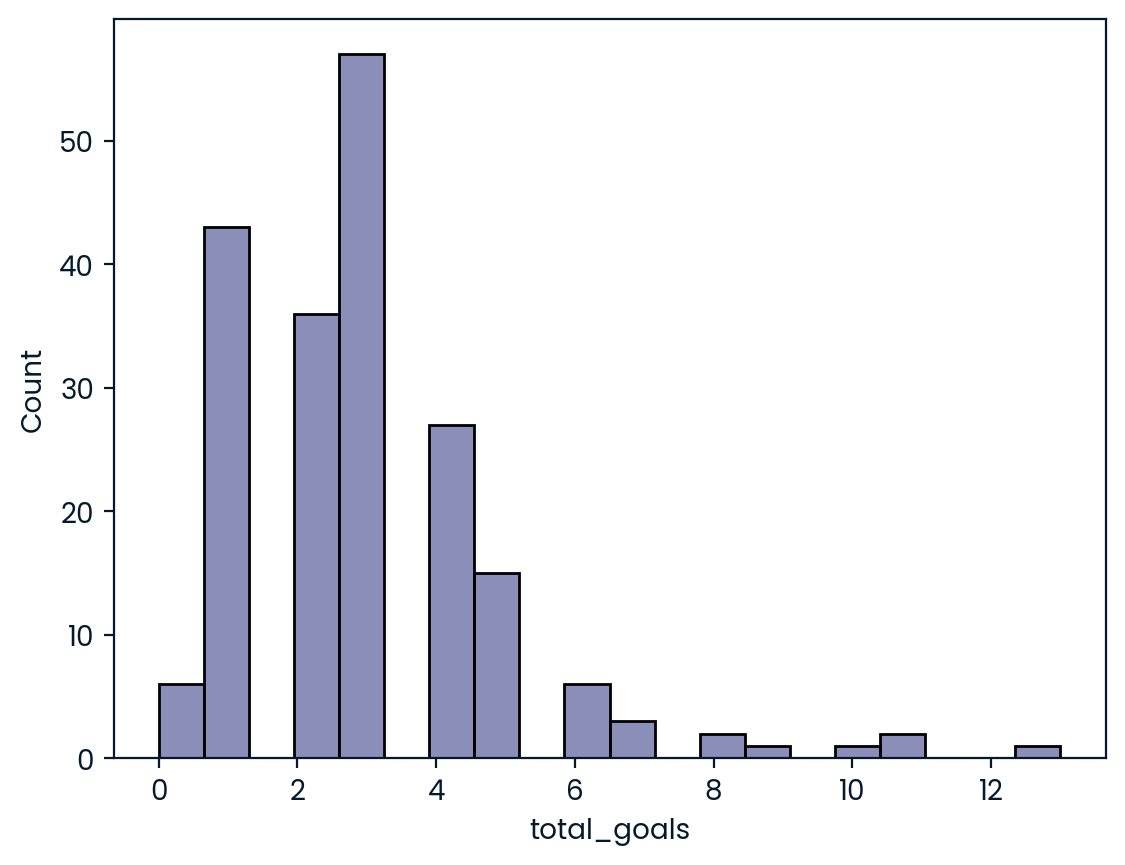

<Figure size 640x480 with 0 Axes>

In [159]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure filtering matches expected dataset
selected_men_df = df_men[
    (df_men["date"] >= "2002-01-01") &
    (df_men["tournament"] == "FIFA World Cup")
].copy()

selected_women_df = df_women[
    (df_women["date"] >= "2002-01-01") &
    (df_women["tournament"] == "FIFA World Cup")
].copy()

# Create total goals column
selected_men_df["total_goals"] = selected_men_df["home_score"] + selected_men_df["away_score"]
selected_women_df["total_goals"] = selected_women_df["home_score"] + selected_women_df["away_score"]

# Histograms for assumption check
sns.histplot(data=selected_men_df, x="total_goals")
plt.show()
plt.clf()

sns.histplot(data=selected_women_df, x="total_goals")
plt.show()
plt.clf()

In [160]:
from scipy.stats import shapiro
import pingouin as pg

# Normality checks
print(shapiro(selected_men_df["total_goals"]))
print(shapiro(selected_women_df["total_goals"]))

# Since shapiro wilk test shows that our datasets are not normally distributed, we use Mann Whitney U test 
res = pg.mwu(
    x=selected_women_df["total_goals"],
    y=selected_men_df["total_goals"],
    alternative="greater"
)

# Extract p-value
p_val = res["p-val"].values[0]

# Decision rule
result = "reject" if p_val <= 0.10 else "fail to reject"

# Final output
result_dict = {
    "p_val": p_val,
    "result": result
}

print(result_dict)

ShapiroResult(statistic=0.9266489744186401, pvalue=8.894154401688226e-13)
ShapiroResult(statistic=0.8491013050079346, pvalue=3.8905201759850683e-13)
{'p_val': 0.005106609825443641, 'result': 'reject'}
